In [189]:
# importing libraries
import math
import os
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline
from graphviz import Digraph

In [377]:
class Engine:
    def __init__(self,data,children = (),_op='',label=''):
        self.data = data
        self.prev = set(children)
        self.label = label
        self._op = _op
        self._backward = lambda : None
        self.grad = 0.0
    def __rmul__(self,other):
        return self * other
    def __radd__(self, other):
        return self + other
    def __repr__(self):
        return f"(value={self.data})"
    def __sub__(self, other):
        return self + (-other)
    def __add__(self, other):
        other = other if isinstance(other, Engine) else Engine(other)
        out = Engine(self.data + other.data,(self,other),'+' )
        def _backward():
            self.grad += out.grad
            other.grad += out.grad 
        out._backward = _backward
        return out
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Engine(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += other * (self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out
    def __mul__(self, other):
        other = other if isinstance(other, Engine) else Engine(other)
        out = Engine(self.data*other.data, (self,other),'*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def relu(self):
        out = Engine(max(0,self.data), (self,), 'relu')
        def _backward():
            self.grad += (1 if out.data > 0 else 0) * out.grad
        out._backward = _backward
        return out
    def __truediv__(self, other):
        other = other if isinstance(other, Engine) else Engine(other)
        return self * other**-1
    def backward(self):
        self.grad = 1.0
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        for node in reversed(topo):
            node._backward()

In [290]:
x1 = Engine(2.0); x1.label = 'x1'
x2 = Engine(3.0); x2.label = 'x2'
w1 = Engine(1.0); w1.label = 'w1'
w2 = Engine(0.0); w2.label = 'w2'
b = Engine(6.887877787); b.label = 'b'

In [273]:
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1x2w2"
val = x1w1x2w2 + b; val.label = 'out'
data = val.relu(); data.label = 'relu'
print(data.prev)
print(data._op)
print(data.data)

{(value=8.887877787)}
relu
8.887877787


In [272]:
## Visualizing the graph

def createNodesEdges(val):
    nodes, edges = set() , set()
    def build(data):
        if data not in nodes:
            nodes.add(data)
            for adj in data.prev:
                edges.add((adj, data))
                build(adj)
    build(val)
    return nodes, edges

def drawgraph(someValue):
    dot = Digraph(format="svg")
    dot.attr(rankdir="LR")  
    nodes , edges = createNodesEdges(someValue)

    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{<out> %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid+n._op, label=n._op)
            dot.edge(uid+n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)
    
    return dot

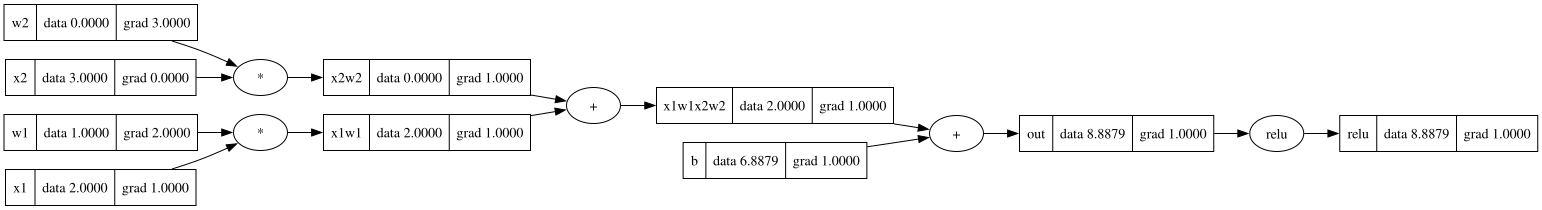

In [276]:
drawgraph(data)

In [275]:
data.backward()

In [395]:
## Implementing neuron

class Neuron:
    def __init__(self,nin, nonLinear=True):
        self.weights = [Engine(random.uniform(-1,1)) for _ in range(nin)]
        self.bias = Engine(0.1)
        self.nonLinear = nonLinear
    def __call__(self,x):
        sumOfall = sum(x*w for x,w in zip(x,self.weights)) + self.bias
        out = sumOfall.relu() if self.nonLinear else sumOfall
        return out
    def parameters(self):
        return self.weights + [self.bias]

In [397]:
## creating Layer
class Layer:
    def __init__(self, nin, nout, nonLinear=True):
        self.neurons = [Neuron(nin, nonLinear) for _ in range(nout)]
    def __call__(self, x):
        output = [neuron(x) for neuron in self.neurons]
        return output[0] if len(output) == 1 else output
    def parameters(self):
        params = []
        for neuron in self.neurons:
            params += neuron.parameters()
        return params


In [398]:
## Multilayer perceptron
## (3,[4,4,2])
class MLP:
    def __init__(self, nin, nouts):
        size = [nin]+nouts
        self.layers = [Layer(size[i], size[i+1], i != len(nouts)-1) for i in range(len(nouts))]
    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        params = []
        for layer in self.layers:
            params += layer.parameters()
        return params

In [ ]:
x = [2.0,3.0]

n = MLP(2,[3,3,1])

y = n(x)
y.backward()
drawgraph(y)

In [ ]:
## Creating small dataset and predict the value using custom function or pytorch
X = [[2.0, 3.0, -1.0], [3.0,-1.0,0.5], [0.5, 1.0, 1.0], [1.0, 1.0, -1.0]] # inputs
Y = [1.0, -1.0, 1.0, -1.0] # desired output

n = MLP(3, [4, 4, 1])
parameters = n.parameters()


In [412]:
## let try to reduce the loss in iterative way
for _ in range(20):
    ## forward pass
    ypred = [n(x) for x in X]

    ## loss calculation
    losses = [(yout - ygt)**2 for ygt, yout in zip(Y, ypred)]
    loss = sum(losses)
    ## set the grads to zero
    for p in parameters:
        p.grad = 0.0
    
    ## backward pass
    loss.backward()
    ## update the weights
    for p in parameters:
        p.data += -0.01 * p.grad
    

    print(loss)


(value=0.15407561428123184)
(value=0.14988729247431137)
(value=0.14582024597942322)
(value=0.14203141624295504)
(value=0.15068210555308942)
(value=0.13914959280488412)
(value=0.1345040651914753)
(value=0.13072273418927577)
(value=0.12708109368561432)
(value=0.12356134940361835)
(value=0.12015099157981493)
(value=0.11684097181922826)
(value=0.11362458997097065)
(value=0.11049673947731742)
(value=0.10745339720988047)
(value=0.10449127932292193)
(value=0.1017910167330034)
(value=0.09964672627409113)
(value=0.09648698867530121)
(value=0.09379498170688133)


In [413]:
ypred = [n(x) for x in X]
print(ypred)

[(value=0.9908431400756638), (value=-1.0449972498195046), (value=0.7409484505150324), (value=-0.8517975596019293)]


In [ ]:
## via the above code you can see we are close to get the actual y (desired output)
## but there is still one issue, because we are applying relu on all the nuerons (even on output neuron) then no matter how better
## i train my model it wll always give 0 when output neuron data is negative, so the fix is simple just apply relu to only hidden layers
## not the output so that we will get output as is. (Let's update the code)

In [422]:
X = torch.tensor(X)
Y = torch.tensor(Y)

/var/folders/d9/dl4544bx19v449kyv_tv8c_00000gn/T/ipykernel_60292/3876772689.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X)
/var/folders/d9/dl4544bx19v449kyv_tv8c_00000gn/T/ipykernel_60292/3876772689.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(Y)


In [425]:
g = torch.Generator().manual_seed(42)
W1 = torch.randn([3,4], generator = g, requires_grad=True)
W2 = torch.randn([4,4], generator = g, requires_grad=True)
W3 = torch.randn([4,1], generator = g, requires_grad=True)
b1 = torch.randn(4, generator=g, requires_grad=True)
b2 = torch.randn(4, generator=g, requires_grad=True)
b3 = torch.randn(1, generator=g, requires_grad=True)

parameters = [W1,W2, W2, b1, b2, b3]


In [440]:
for _ in range(20):
    h1 = (X @ W1 + b1).relu()
    h2 = (h1 @ W2 + b2).relu()
    ypred = h2 @ W3 + b3          

    loss = ((ypred - Y) ** 2).mean()

    for p in parameters:
        p.grad = None
    
    loss.backward()

    with torch.no_grad():
        for p in parameters:
                p -= 0.01 * p.grad

    print(it, loss.item())


19 1.0
19 0.9999999403953552
19 1.0
19 1.0
19 0.9999999403953552
19 1.0
19 1.0
19 1.0
19 0.9999999403953552
19 1.0
19 1.0
19 1.0
19 0.9999999403953552
19 1.0
19 1.0
19 1.0
19 0.9999999403953552
19 1.0
19 1.0
19 1.0


In [441]:
ypred = h2 @ W3 + b3
ypred

tensor([[1.2452e-06],
        [1.2452e-06],
        [1.2452e-06],
        [1.2452e-06]], grad_fn=<AddBackward0>)